In [20]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.tools import tool
from typing import TypedDict, Annotated
from pydantic import Field
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [4]:
load_dotenv()

True

In [5]:
model = ChatGroq(
    model='openai/gpt-oss-120b',
    temperature=0.7
)

In [6]:
loader = PyPDFLoader(r'C:\Desktop\LangGraph\intro-to-ml.pdf')
docs = loader.load()

In [7]:
len(docs)

392

In [9]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [10]:
len(chunks)

973

In [11]:
embedding = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
vector_store = FAISS.from_documents(chunks, embedding)

In [13]:
vector_store

In [14]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k': 4})

In [17]:
@tool
def rag_tool(query):
    """ Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents """

    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.page_content for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [18]:
tools = [rag_tool]
llm_with_tools = model.bind_tools(tools)

In [21]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [23]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [24]:
tool_node = ToolNode(tools)

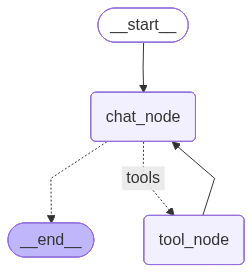

In [29]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tool_node', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition, {'tools': 'tool_node', '__end__': END})
graph.add_edge('tool_node', 'chat_node')

workflow = graph.compile()

workflow

In [31]:
result = workflow.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain how to find the ideal value of K in KNN"
                )
            )
        ]
    }
)

In [33]:
print(result['messages'][-1].content)

**How to pick the “right” *K* for a k‑Nearest‑Neighbors (k‑NN) model**

The PDF notes (see the plot labelled *Figure 2‑7 – Comparison of training and test accuracy as a function of n_neighbors*) give a concrete, visual recipe for finding the ideal value of *K*.  The idea is to look at how the model behaves on data it has seen (training set) versus data it has not seen (validation or test set) as you vary *K*.  Below is a step‑by‑step guide that follows exactly what the notes illustrate.

---

### 1. Create a validation scheme  

| Option | What you do | Why it helps |
|--------|-------------|--------------|
| **Hold‑out split** – e.g. 70 % train / 30 % test | Randomly separate the data once. | Gives a quick estimate of test performance. |
| **k‑fold cross‑validation** (commonly k = 5 or 10) | Partition the data into *k* folds, train on *k‑1* folds and evaluate on the remaining fold; repeat for each fold and average the scores. | Reduces the variance of the performance estimate, especia